# Main Baseline Visualization

Reads cached benchmark outputs and recreates the main-baseline figures.

In [22]:
from __future__ import annotations

from pathlib import Path
import csv
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "configs").exists() and (path / "src").exists():
            return path
    return Path(r"C:\Users\laipeiheng\Desktop\CCVNet")


REPO_ROOT = find_repo_root()
RESULT_CACHE_ROOT = (REPO_ROOT / "results").resolve()
FIGURE_DIR = REPO_ROOT / "Visualization" / "Graph"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = REPO_ROOT / "results" / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
PREFIX_CYCLES = [20, 30, 40, 50, 60, 70, 80, 90, 100]


def normalize_model_name(value):
    return str(value)


def display_model_unit(unit):
    text = str(unit)
    if "/" not in text:
        return normalize_model_name(text)
    input_mode, model = text.split("/", 1)
    return f"{input_mode}/{normalize_model_name(model)}"


def normalize_cache_frame(df: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(df, pd.DataFrame) or df.empty:
        return df
    return df.copy()


def result_cache_dirs(experiment_name: str, branch: str | None = None) -> list[tuple[str, Path]]:
    branches = [branch] if branch else ["major", "ablation"]
    dirs = []
    for branch_name in branches:
        cache_dir = RESULT_CACHE_ROOT / branch_name / experiment_name
        if cache_dir.exists():
            dirs.append((branch_name, cache_dir))
    return dirs


def load_cached_dir_frames(cache_dir: str | Path, frame_names: list[str]) -> dict[str, pd.DataFrame]:
    cache_dir = Path(cache_dir)
    frames = {}
    for frame_name in frame_names:
        path = cache_dir / f"{frame_name}.csv"
        if path.exists() and path.stat().st_size > 0:
            try:
                frames[frame_name] = normalize_cache_frame(pd.read_csv(path))
            except pd.errors.EmptyDataError:
                frames[frame_name] = pd.DataFrame()
        else:
            frames[frame_name] = pd.DataFrame()
    return frames


def summarize_metric_repeats(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    present_group_cols = [col for col in group_cols if col in df.columns]
    metric_cols = [
        col for col in ["mape", "rmse", "mae", "pearson_r", "r2"]
        if col in df.columns
    ]
    if not metric_cols:
        metric_cols = [
            col for col in df.select_dtypes(include=[np.number]).columns
            if col not in present_group_cols and not str(col).endswith("_std")
        ]
    grouped = df.groupby(present_group_cols, dropna=False)[metric_cols].agg(["mean", "std"]).reset_index()
    grouped.columns = [
        col[0] if col[1] == "" else (col[0] if col[1] == "mean" else f"{col[0]}_std")
        for col in grouped.columns.to_flat_index()
    ]
    return grouped


def print_cache_root() -> None:
    print(f"CCVNet repo: {REPO_ROOT}")
    print(f"Result cache root: {RESULT_CACHE_ROOT}")

print_cache_root()


def _finite_pairs(y_true, y_pred):
    pairs = []
    for truth, pred in zip(y_true, y_pred):
        try:
            truth = float(truth)
            pred = float(pred)
        except Exception:
            continue
        if np.isfinite(truth) and np.isfinite(pred):
            pairs.append((truth, pred))
    return pairs


def regression_metrics(y_true, y_pred):
    pairs = _finite_pairs(y_true, y_pred)
    if not pairs:
        return {"rmse": np.nan, "mae": np.nan, "mape": np.nan, "pearson_r": np.nan}
    truth = np.asarray([p[0] for p in pairs], dtype=float)
    pred = np.asarray([p[1] for p in pairs], dtype=float)
    err = pred - truth
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    valid_pct = np.abs(truth) > 1e-12
    mape = float(np.mean(np.abs(err[valid_pct] / truth[valid_pct])) * 100.0) if valid_pct.any() else np.nan
    pearson_r = float(pd.Series(truth).corr(pd.Series(pred), method="pearson")) if len(truth) >= 2 else np.nan
    return {"rmse": rmse, "mae": mae, "mape": mape, "pearson_r": pearson_r}


CCVNet repo: c:\Users\laipeiheng\Desktop\CCVNet
Result cache root: C:\Users\laipeiheng\Desktop\CCVNet\results


In [23]:
print(f"main_baseline cache: {RESULT_CACHE_ROOT / 'major' / 'main_baseline'}")
print(f"main_baseline ablation cache: {RESULT_CACHE_ROOT / 'ablation' / 'main_baseline'}")


main_baseline cache: C:\Users\laipeiheng\Desktop\CCVNet\results\major\main_baseline
main_baseline ablation cache: C:\Users\laipeiheng\Desktop\CCVNet\results\ablation\main_baseline


In [24]:
main_baseline_loaded_rows = []
main_baseline_overall_metric_frames = []
main_baseline_dataset_metric_frames = []
main_baseline_prediction_frames = []
main_baseline_skipped_frames = []

for branch_name, cache_dir in result_cache_dirs("main_baseline"):
    frames = load_cached_dir_frames(
        cache_dir,
        ["overall_metric_df", "dataset_metric_df", "prediction_df", "skipped_df"],
    )
    for frame_name, frame in frames.items():
        if isinstance(frame, pd.DataFrame) and not frame.empty and "plot_group" not in frame.columns:
            frames[frame_name] = frame.assign(plot_group=branch_name)
    if not frames["overall_metric_df"].empty:
        main_baseline_overall_metric_frames.append(frames["overall_metric_df"])
    if not frames["dataset_metric_df"].empty:
        main_baseline_dataset_metric_frames.append(frames["dataset_metric_df"])
    if not frames["prediction_df"].empty:
        main_baseline_prediction_frames.append(frames["prediction_df"])
    if not frames["skipped_df"].empty:
        main_baseline_skipped_frames.append(frames["skipped_df"])
    main_baseline_loaded_rows.append(
        {
            "branch": branch_name,
            "cache_dir": str(cache_dir),
            "overall_rows": len(frames["overall_metric_df"]),
            "dataset_rows": len(frames["dataset_metric_df"]),
            "prediction_rows": len(frames["prediction_df"]),
        }
    )

main_baseline_overall_metric_df = pd.concat(main_baseline_overall_metric_frames, ignore_index=True) if main_baseline_overall_metric_frames else pd.DataFrame()
main_baseline_dataset_metric_df = pd.concat(main_baseline_dataset_metric_frames, ignore_index=True) if main_baseline_dataset_metric_frames else pd.DataFrame()
main_baseline_prediction_df = pd.concat(main_baseline_prediction_frames, ignore_index=True) if main_baseline_prediction_frames else pd.DataFrame()
main_baseline_skipped_df = pd.concat(main_baseline_skipped_frames, ignore_index=True) if main_baseline_skipped_frames else pd.DataFrame()

main_baseline_overall_summary_df = summarize_metric_repeats(
    main_baseline_overall_metric_df,
    ["split_protocol", "input_mode", "model", "plot_group"],
) if not main_baseline_overall_metric_df.empty else pd.DataFrame()
main_baseline_dataset_summary_df = summarize_metric_repeats(
    main_baseline_dataset_metric_df,
    ["split_protocol", "input_mode", "model", "dataset_name", "plot_group"],
) if not main_baseline_dataset_metric_df.empty else pd.DataFrame()

print("Main baseline repo cache coverage:")
display(pd.DataFrame(main_baseline_loaded_rows))

main_baseline_overall_display_cols = [
    "split_protocol",
    "input_mode",
    "model",
    "plot_group",
    "mape",
    "mape_std",
    "rmse",
    "rmse_std",
    "mae",
    "pearson_r",
]

print("Main baseline overall benchmark summary:")
if main_baseline_overall_summary_df.empty:
    print("No main baseline summary rows found in repo cache.")
else:
    display(
        main_baseline_overall_summary_df.loc[:, [c for c in main_baseline_overall_display_cols if c in main_baseline_overall_summary_df.columns]]
        .sort_values(["plot_group", "split_protocol", "input_mode", "mape", "model"], ascending=[True, True, True, True, True])
        .reset_index(drop=True)
        .round(3)
    )


Main baseline repo cache coverage:


,branch,cache_dir,overall_rows,dataset_rows,prediction_rows
0,major,C:\Users\laipeiheng\Desktop\CCVNet\results\maj...,45,360,7785
1,ablation,C:\Users\laipeiheng\Desktop\CCVNet\results\abl...,180,1320,30060


Main baseline overall benchmark summary:


,split_protocol,input_mode,model,plot_group,mape,mape_std,rmse,rmse_std,mae,pearson_r
0,fine-group split,abs,CCV-abs-cycleaware,ablation,12.605,1.759,169.247,18.022,101.737,0.942
1,fine-group split,abs,SpectrumNN,ablation,12.979,1.591,168.433,16.884,101.630,0.942
2,fine-group split,abs,Spectrum-descriptor,ablation,13.157,1.336,178.232,48.340,107.287,0.936
3,fine-group split,abs,Descriptor,ablation,13.414,1.730,177.245,43.955,106.217,0.936
4,fine-group split,abs,Descriptor-meta,ablation,14.308,0.788,180.610,32.285,108.696,0.936
5,fine-group split,abs,Spectrum-meta,ablation,14.442,1.559,195.030,38.680,114.872,0.924
6,fine-group split,abs,CNN,ablation,14.803,1.332,182.491,15.854,111.520,0.933
7,fine-group split,norm,CCV-norm,ablation,12.320,1.925,157.514,17.941,94.969,0.950
8,fine-group split,norm,Descriptor-meta,ablation,12.667,1.032,178.059,41.974,103.104,0.936
9,fine-group split,norm,Spectrum-descriptor,ablation,13.113,1.576,171.364,35.624,103.675,0.939


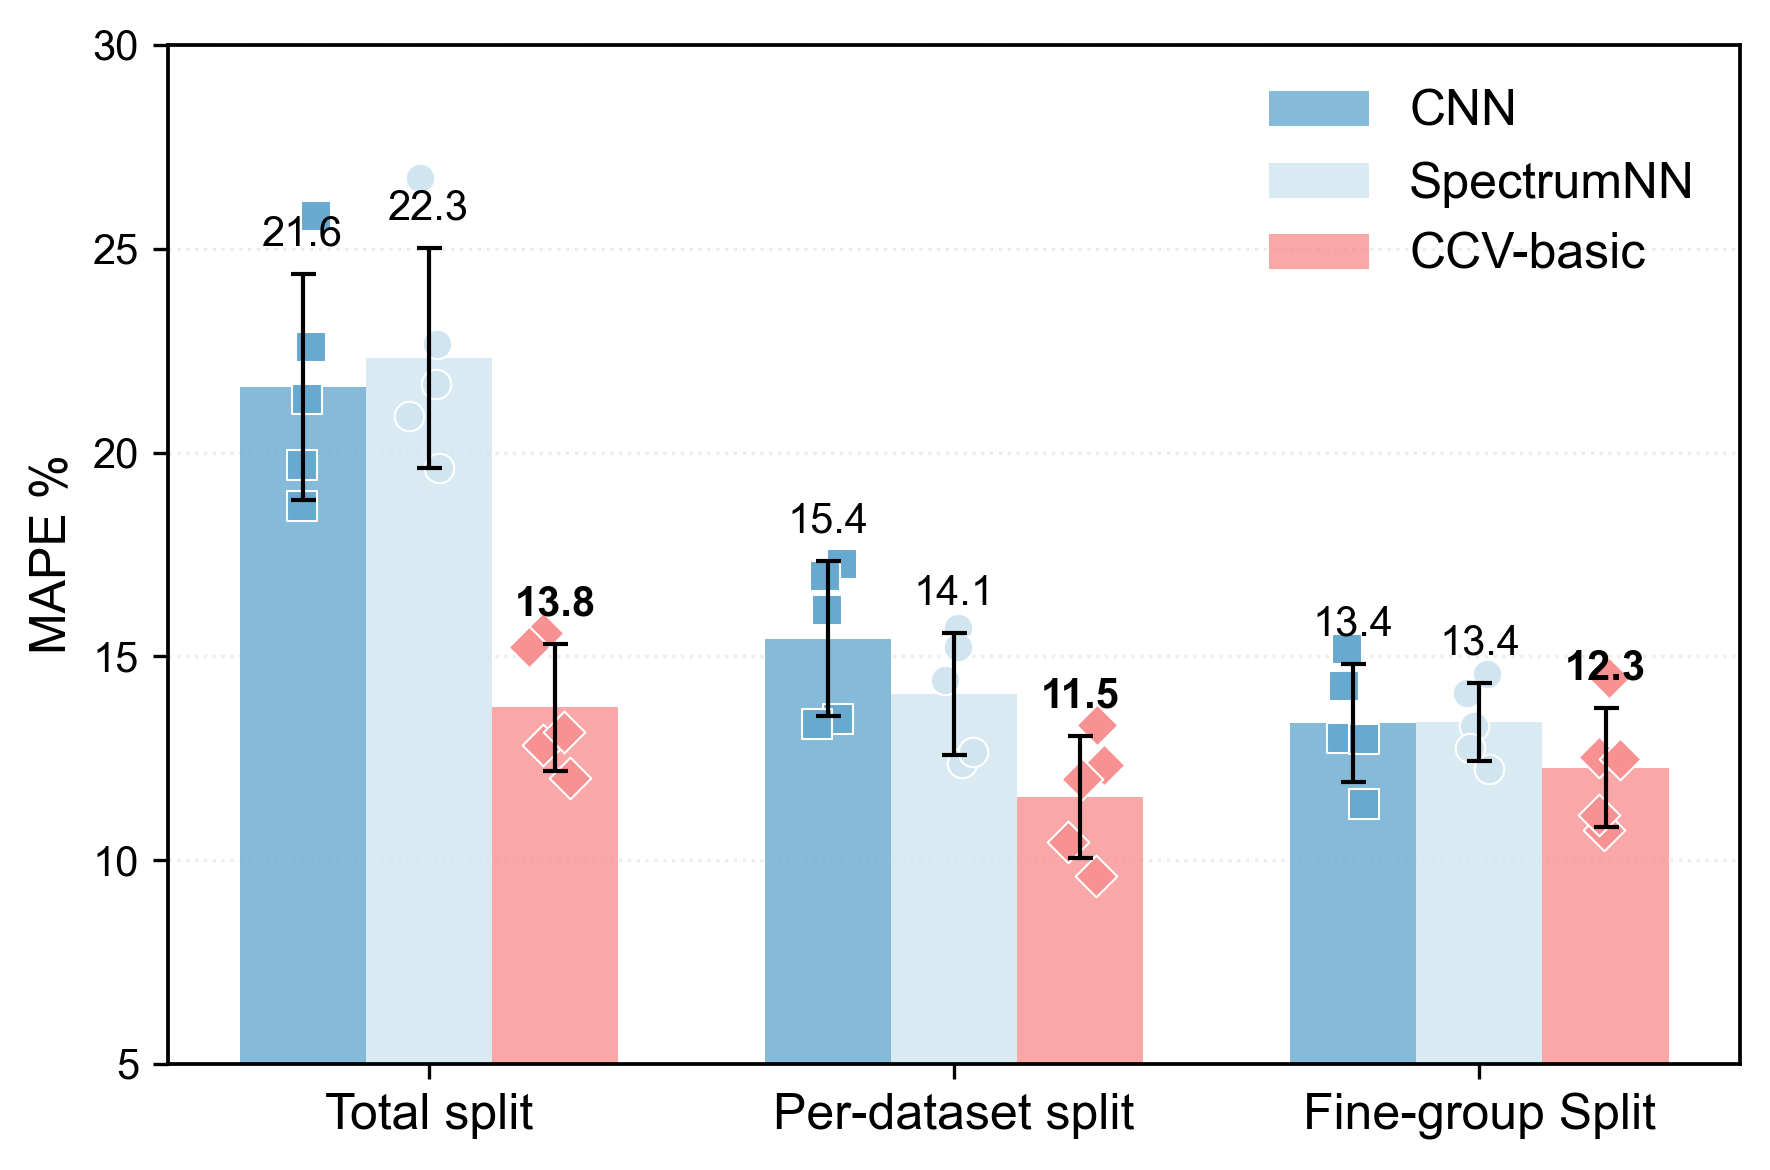

In [25]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"]
})

major_df = main_baseline_overall_summary_df.loc[main_baseline_overall_summary_df["plot_group"].eq("major")].copy()
if major_df.empty:
    print("No major benchmark rows found in Main baseline cache.")
else:

    split_order = ["total split", "per-dataset split", "fine-group split"]
    split_label_map = {
        "total split": "Total split",
        "per-dataset split": "Per-dataset split",
        "fine-group split": "Fine-group Split",
    }

    major_specs = [
        ("CNN", "norm"),
        ("SpectrumNN", "norm"),
        ("CCV-basic", "abs"),
    ]
    label_map = {
        ("CNN", "norm"): "CNN",
        ("SpectrumNN", "norm"): "SpectrumNN",
        ("CCV-basic", "abs"): "CCV-basic",
    }
    palette = {
        ("CNN", "norm"): "#67a9cf",
        ("SpectrumNN", "norm"): "#d1e5f0",
        ("CCV-basic", "abs"): "#f89191",
    }
    scatter_style = {
        ("CNN", "norm"): dict(marker="s"),
        ("SpectrumNN", "norm"): dict(marker="o"),
        ("CCV-basic", "abs"): dict(marker="D"),
    }

    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
    x = np.arange(len(split_order), dtype=float)
    width = 0.24

    for idx, spec_key in enumerate(major_specs):
        model_name, input_mode = spec_key
        sub = (
            major_df.loc[
                major_df["model"].eq(model_name)
                & major_df["input_mode"].eq(input_mode)
            ]
            .set_index("split_protocol")
            .reindex(split_order)
            .reset_index()
        )

        xpos = x + (idx - 1) * width
        mean_values = sub["mape"].to_numpy(dtype=float)
        std_values = sub["mape_std"].fillna(0.0).to_numpy(dtype=float)

        bars = ax.bar(
            xpos,
            mean_values,
            width=width,
            color=palette[spec_key],
            edgecolor="none",
            linewidth=0.0,
            alpha=0.8,
            zorder=2,
            label=label_map[spec_key],
        )

        ax.errorbar(
            xpos,
            mean_values,
            yerr=std_values,
            fmt="none",
            capsize=3,
            elinewidth=1.0,
            capthick=1.0,
            ecolor="#000000",
            alpha=1.0,
            zorder=5,
        )

        metric_sub = main_baseline_overall_metric_df.loc[
            main_baseline_overall_metric_df["plot_group"].eq("major")
            & main_baseline_overall_metric_df["model"].eq(model_name)
            & main_baseline_overall_metric_df["input_mode"].eq(input_mode)
        ].copy()

        rng = np.random.default_rng(700 + idx)
        for split_idx, split_name in enumerate(split_order):
            rep_sub = metric_sub.loc[metric_sub["split_protocol"].eq(split_name)].copy()
            if rep_sub.empty:
                continue
            jitter = rng.normal(0.0, width * 0.10, size=len(rep_sub))
            scatter_x = np.full(len(rep_sub), xpos[split_idx], dtype=float) + jitter
            scatter_y = rep_sub["mape"].to_numpy(dtype=float)
            ax.scatter(
                scatter_x,
                scatter_y,
                s=50,
                facecolor=palette[spec_key],
                edgecolor="white",
                linewidth=0.5,
                zorder=4,
                **scatter_style[spec_key],
            )

        for bar, mean_v, std_v in zip(bars, mean_values, std_values):
            if np.isfinite(mean_v):
                y_text = mean_v + std_v + 0.5
                ax.text(
                    bar.get_x() + bar.get_width() / 2.0,
                    y_text,
                    f"{mean_v:.1f}",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                    color="#000000",
                    fontweight="bold" if spec_key == ("CCV-basic", "abs") else "normal",
                    zorder=5,
                )

    ax.set_xticks(x)
    ax.set_xticklabels([split_label_map[s] for s in split_order], fontsize=12)
    ax.set_ylabel("MAPE %", fontsize=12)
    ax.set_yticks([5, 10, 15, 20, 25, 30])
    ax.set_ylim(5, 30)
    ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.22, zorder=0)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_linewidth(0.9)
        spine.set_color("#000000")

    ax.tick_params(axis="y", labelsize=10)
    ax.legend(frameon=False, fontsize=12, loc="upper right")
    fig.tight_layout()
    #plt.savefig(FIGURE_DIR / "F3a.tiff", format="tiff", dpi=500, bbox_inches="tight")
    plt.show()

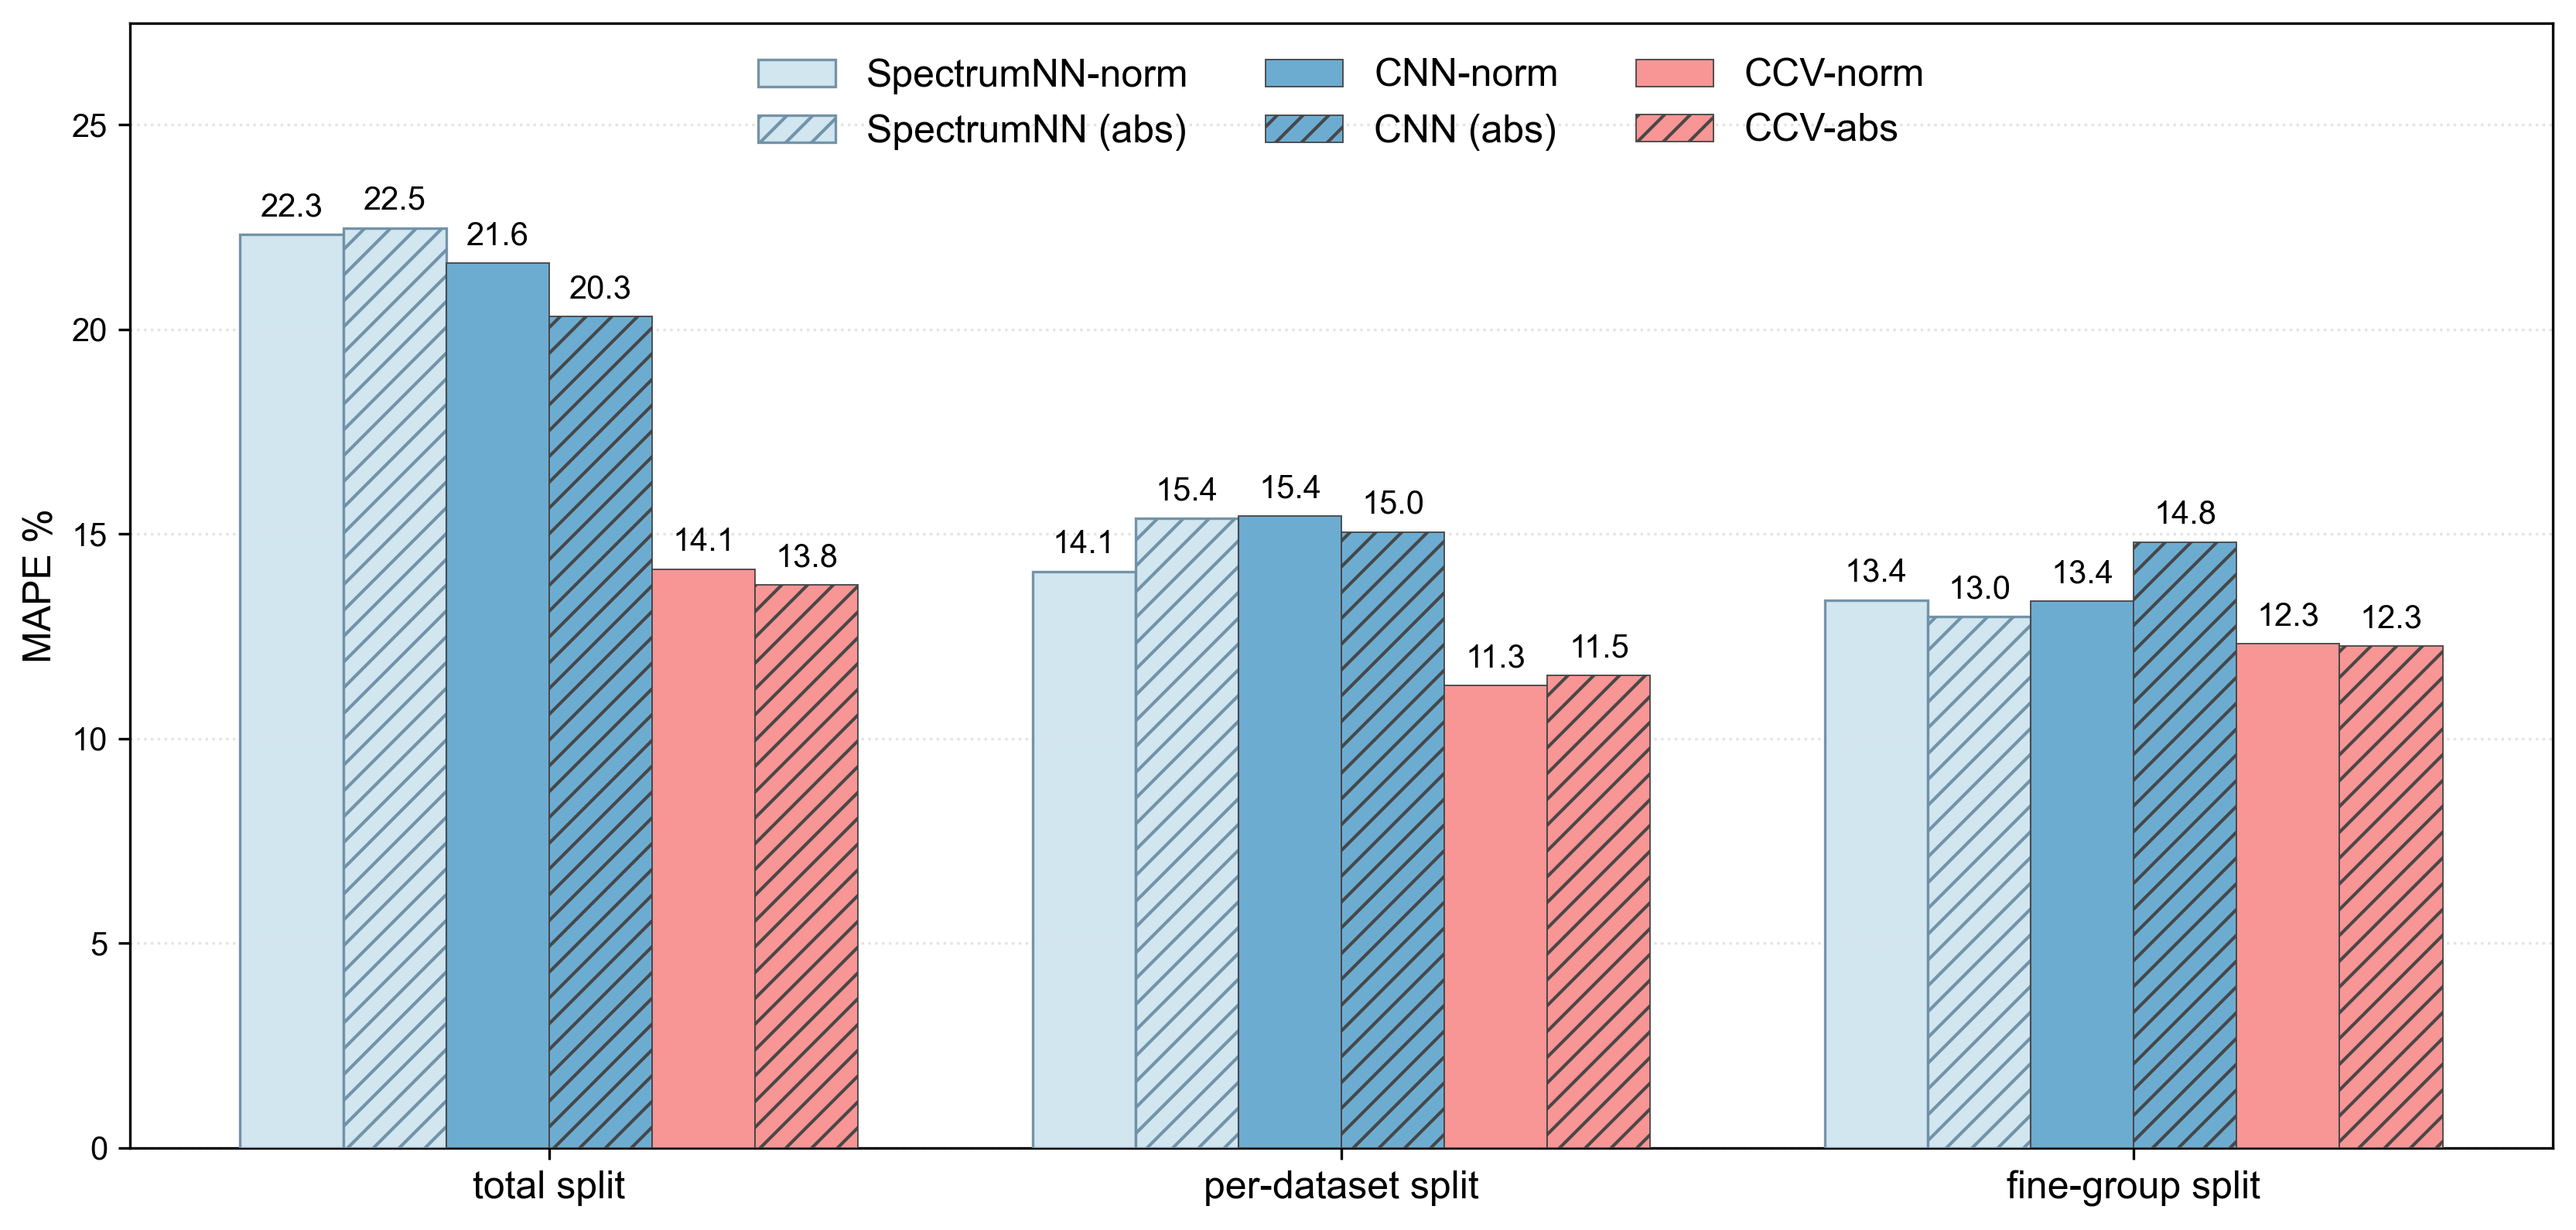

In [ ]:
major_df = main_baseline_overall_summary_df.loc[main_baseline_overall_summary_df["plot_group"].eq("major")].copy()
ablation_df = main_baseline_overall_summary_df.loc[main_baseline_overall_summary_df["plot_group"].eq("ablation")].copy()

plot_frames = []
if not major_df.empty:
    plot_frames.append(
        major_df.loc[
            (
                (major_df["model"].eq("SpectrumNN") & major_df["input_mode"].eq("norm"))
                | (major_df["model"].eq("CNN") & major_df["input_mode"].eq("norm"))
                | (major_df["model"].eq("CCV-basic") & major_df["input_mode"].eq("abs"))
            )
        ].copy()
    )
if not ablation_df.empty:
    plot_frames.append(
        ablation_df.loc[
            (
                (ablation_df["model"].eq("SpectrumNN") & ablation_df["input_mode"].eq("abs"))
                | (ablation_df["model"].eq("CNN") & ablation_df["input_mode"].eq("abs"))
                | (ablation_df["model"].eq("CCV-norm") & ablation_df["input_mode"].eq("norm"))
            )
        ].copy()
    )

plot_df = pd.concat(plot_frames, ignore_index=True) if plot_frames else pd.DataFrame()

if plot_df.empty:
    print("No ablation rows found in Main baseline cache.")
else:
    split_order = ["total split", "per-dataset split", "fine-group split"]
    ablation_specs = [
        ("SpectrumNN", "norm"),
        ("SpectrumNN", "abs"),
        ("CNN", "norm"),
        ("CNN", "abs"),
        ("CCV-norm", "norm"),
        ("CCV-basic", "abs"),
    ]
    label_map = {
        ("SpectrumNN", "norm"): "SpectrumNN-norm",
        ("SpectrumNN", "abs"): "SpectrumNN (abs)",
        ("CNN", "norm"): "CNN-norm",
        ("CNN", "abs"): "CNN (abs)",
        ("CCV-basic", "abs"): "CCV-abs",
        ("CCV-norm", "norm"): "CCV-norm",
    }
    family_color_map = {
        "SpectrumNN": "#d1e5f0",
        "CNN": "#67a9cf",
        "CCV-basic": "#f89191",
        "CCV-norm": "#f89191",
    }
    hatch_map = {
        "norm": "",
        "abs": "///",
    }

    fig, ax = plt.subplots(figsize=(11.2, 5.4), dpi=300)
    x = np.arange(len(split_order), dtype=float)
    width = 0.13

    for idx, spec_key in enumerate(ablation_specs):
        model_name, input_mode = spec_key
        sub = plot_df.loc[
            plot_df["model"].eq(model_name)
            & plot_df["input_mode"].eq(input_mode)
        ].set_index("split_protocol").reindex(split_order).reset_index()
        xpos = x + (idx - (len(ablation_specs) - 1) / 2.0) * width
        face_color = family_color_map[model_name]
        edge_color = "#6e90a6" if model_name == "SpectrumNN" else "#444444"
        bars = ax.bar(
            xpos,
            sub["mape"].to_numpy(dtype=float),
            width=width,
            color=face_color,
            edgecolor=edge_color,
            linewidth=0.8 if model_name == "SpectrumNN" else 0.45,
            hatch=hatch_map[input_mode],
            #yerr=sub["mape_std"].fillna(0.0).to_numpy(dtype=float),
            capsize=2.5,
            error_kw={"elinewidth": 0.8, "ecolor": "#444444"},
            alpha=0.96,
            label=label_map[spec_key],
            zorder=3,
        )
        for bar, value in zip(bars, sub["mape"].to_numpy(dtype=float)):
            if np.isfinite(value):
                ax.text(
                    bar.get_x() + bar.get_width() / 2.0,
                    value + 0.3,
                    f"{value:.1f}",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(split_order, fontsize=12)
    ax.set_ylabel("MAPE %", fontsize=12)
    ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.35, zorder=0)
    ax.set_ylim(0, max(25.0, float(plot_df["mape"].max()) + 5.0))
    ax.legend(frameon=False, fontsize=12, loc="upper center", ncol=3)
    fig.tight_layout()
    #plt.savefig(FIGURE_DIR / "S11-1.tiff", format="tiff", dpi=500, bbox_inches="tight")
    plt.show()


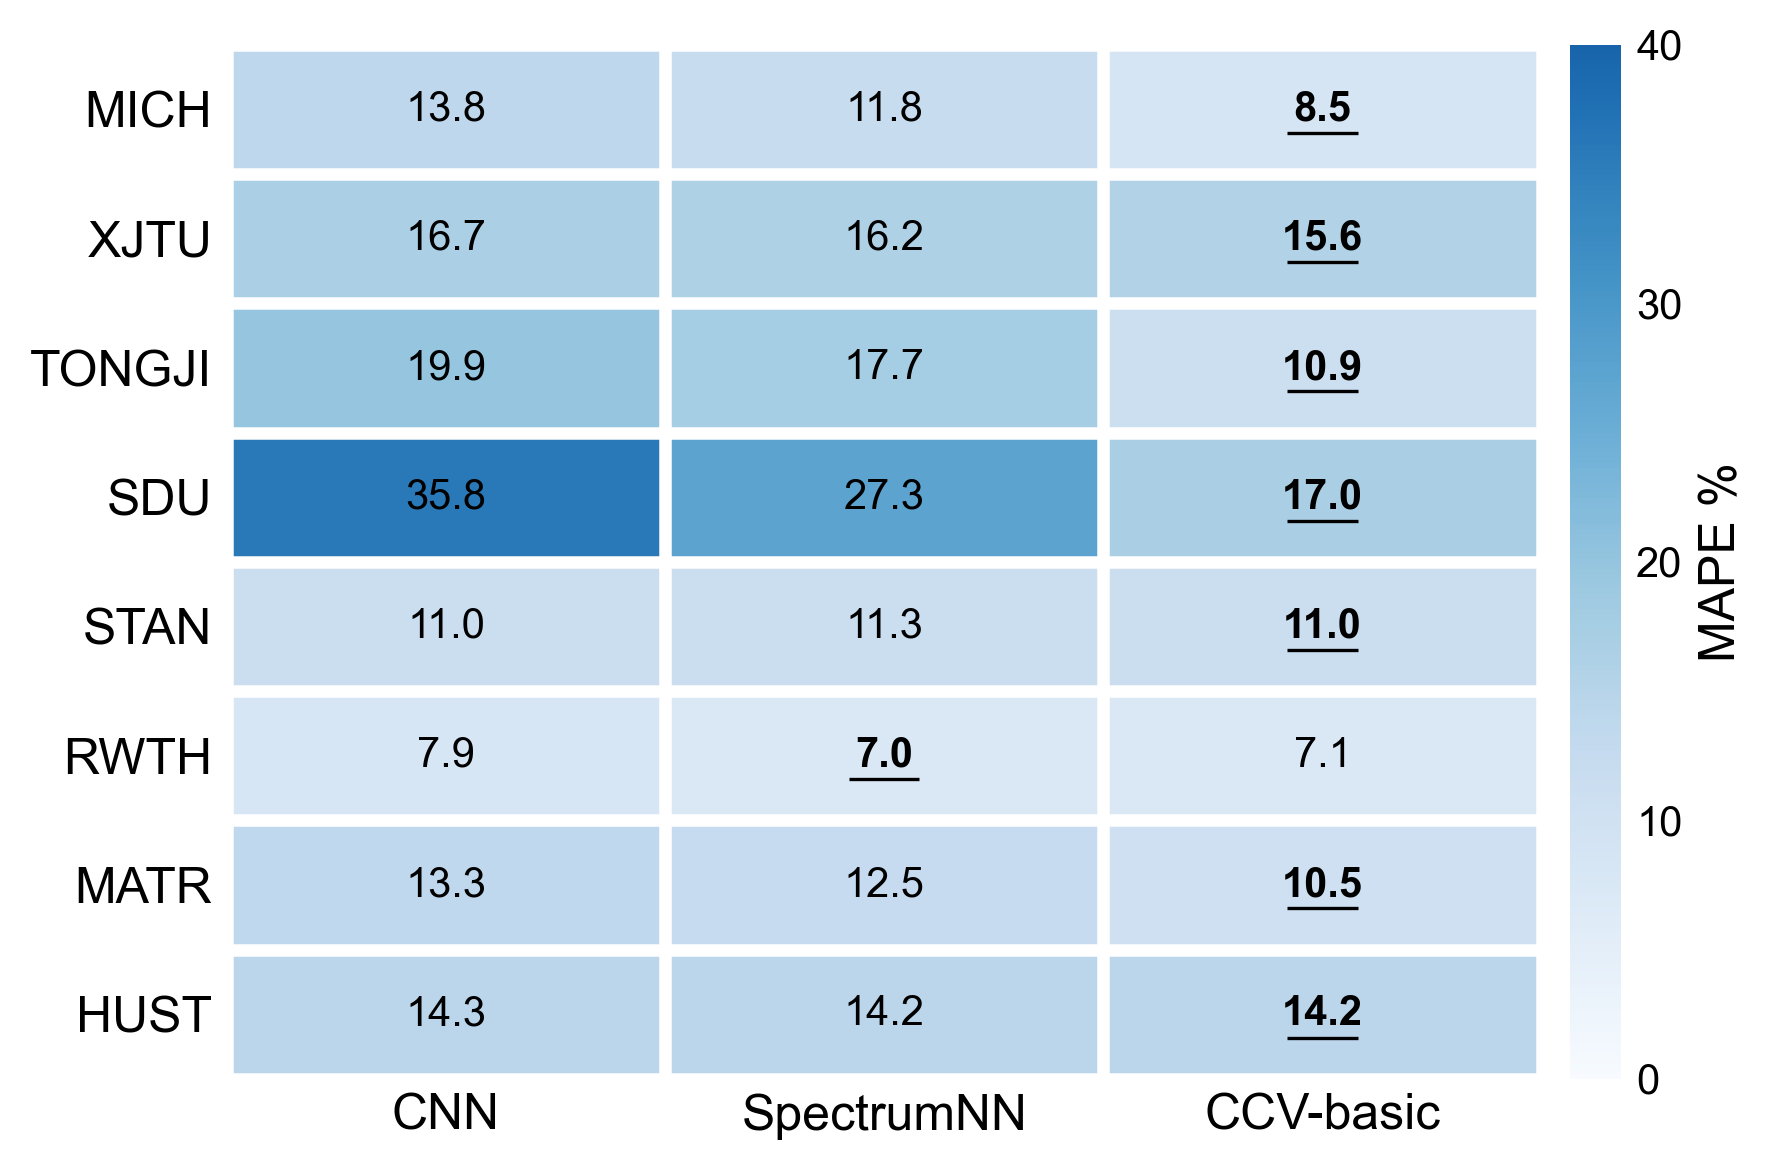

In [27]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"]
})

heatmap_source = main_baseline_dataset_summary_df.loc[
    main_baseline_dataset_summary_df["plot_group"].eq("major")
    & (
        (
            main_baseline_dataset_summary_df["model"].eq("SpectrumNN")
            & main_baseline_dataset_summary_df["input_mode"].eq("norm")
        )
        | (
            main_baseline_dataset_summary_df["model"].eq("CNN")
            & main_baseline_dataset_summary_df["input_mode"].eq("norm")
        )
        | (
            main_baseline_dataset_summary_df["model"].eq("CCV-basic")
            & main_baseline_dataset_summary_df["input_mode"].eq("abs")
        )
    )
    & main_baseline_dataset_summary_df["split_protocol"].eq("per-dataset split")
].copy()

if heatmap_source.empty:
    print("No per-dataset major benchmark rows found for Main baseline heatmap.")
else:
    dataset_order = ["MICH", "XJTU", "TONGJI", "SDU", "STAN", "RWTH", "MATR", "HUST"]
    dataset_order = [d for d in dataset_order if d in heatmap_source["dataset_name"].astype(str).unique().tolist()]
    model_order = ["CNN", "SpectrumNN", "CCV-basic"]

    pivot = (
        heatmap_source.pivot_table(
            index="dataset_name",
            columns="model",
            values="mape",
            aggfunc="mean",
        )
        .reindex(index=dataset_order, columns=model_order)
    )

    data = pivot.to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
    norm = mpl.colors.Normalize(vmin=0, vmax=50)
    im = ax.imshow(data, aspect="auto", cmap="Blues", norm=norm)

    ax.set_xticks(np.arange(len(model_order)))
    ax.set_xticklabels(model_order, fontsize=12)
    ax.set_yticks(np.arange(len(dataset_order)))
    ax.set_yticklabels(dataset_order, fontsize=12)

    ax.set_xticks(np.arange(-0.5, len(model_order), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(dataset_order), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(axis="both", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    for r in range(data.shape[0]):
        row_vals = data[r, :]
        valid_mask = np.isfinite(row_vals)
        if not np.any(valid_mask):
            continue
        row_min = np.nanmin(row_vals)
        for c in range(data.shape[1]):
            value = data[r, c]
            if not np.isfinite(value):
                continue
            is_best = np.isclose(value, row_min, atol=1e-8)
            ax.text(
                c,
                r,
                f"{value:.1f}",
                ha="center",
                va="center",
                fontsize=10,
                color="#000000",
                fontweight="bold" if is_best else "normal",
            )
            if is_best:
                ax.plot(
                    [c - 0.08, c + 0.08],
                    [r + 0.18, r + 0.18],
                    color="#000000",
                    linewidth=0.8,
                    solid_capstyle="butt",
                )

    cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
    cbar.set_label("MAPE %", fontsize=12)
    cbar.set_ticks([0, 10, 20, 30, 40])
    cbar.set_ticklabels(["0", "10", "20", "30", "40"])
    cbar.ax.set_ylim(0, 40)
    cbar.ax.tick_params(labelsize=10, length=0)
    cbar.outline.set_visible(False)

    fig.tight_layout()
    #plt.savefig(FIGURE_DIR / "F3b.tiff", format="tiff", dpi=500, bbox_inches="tight")
    plt.show()


In [28]:
OUT_CSV = TABLE_DIR / "main_baseline_SI_result.csv"
if main_baseline_overall_summary_df.empty:
    print("[Main baseline SI] No summary rows available.")
else:
    main_baseline_overall_summary_df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
    print(f"Main baseline SI_result saved to: {OUT_CSV}")


Main baseline SI_result saved to: c:\Users\laipeiheng\Desktop\CCVNet\results\tables\main_baseline_SI_result.csv


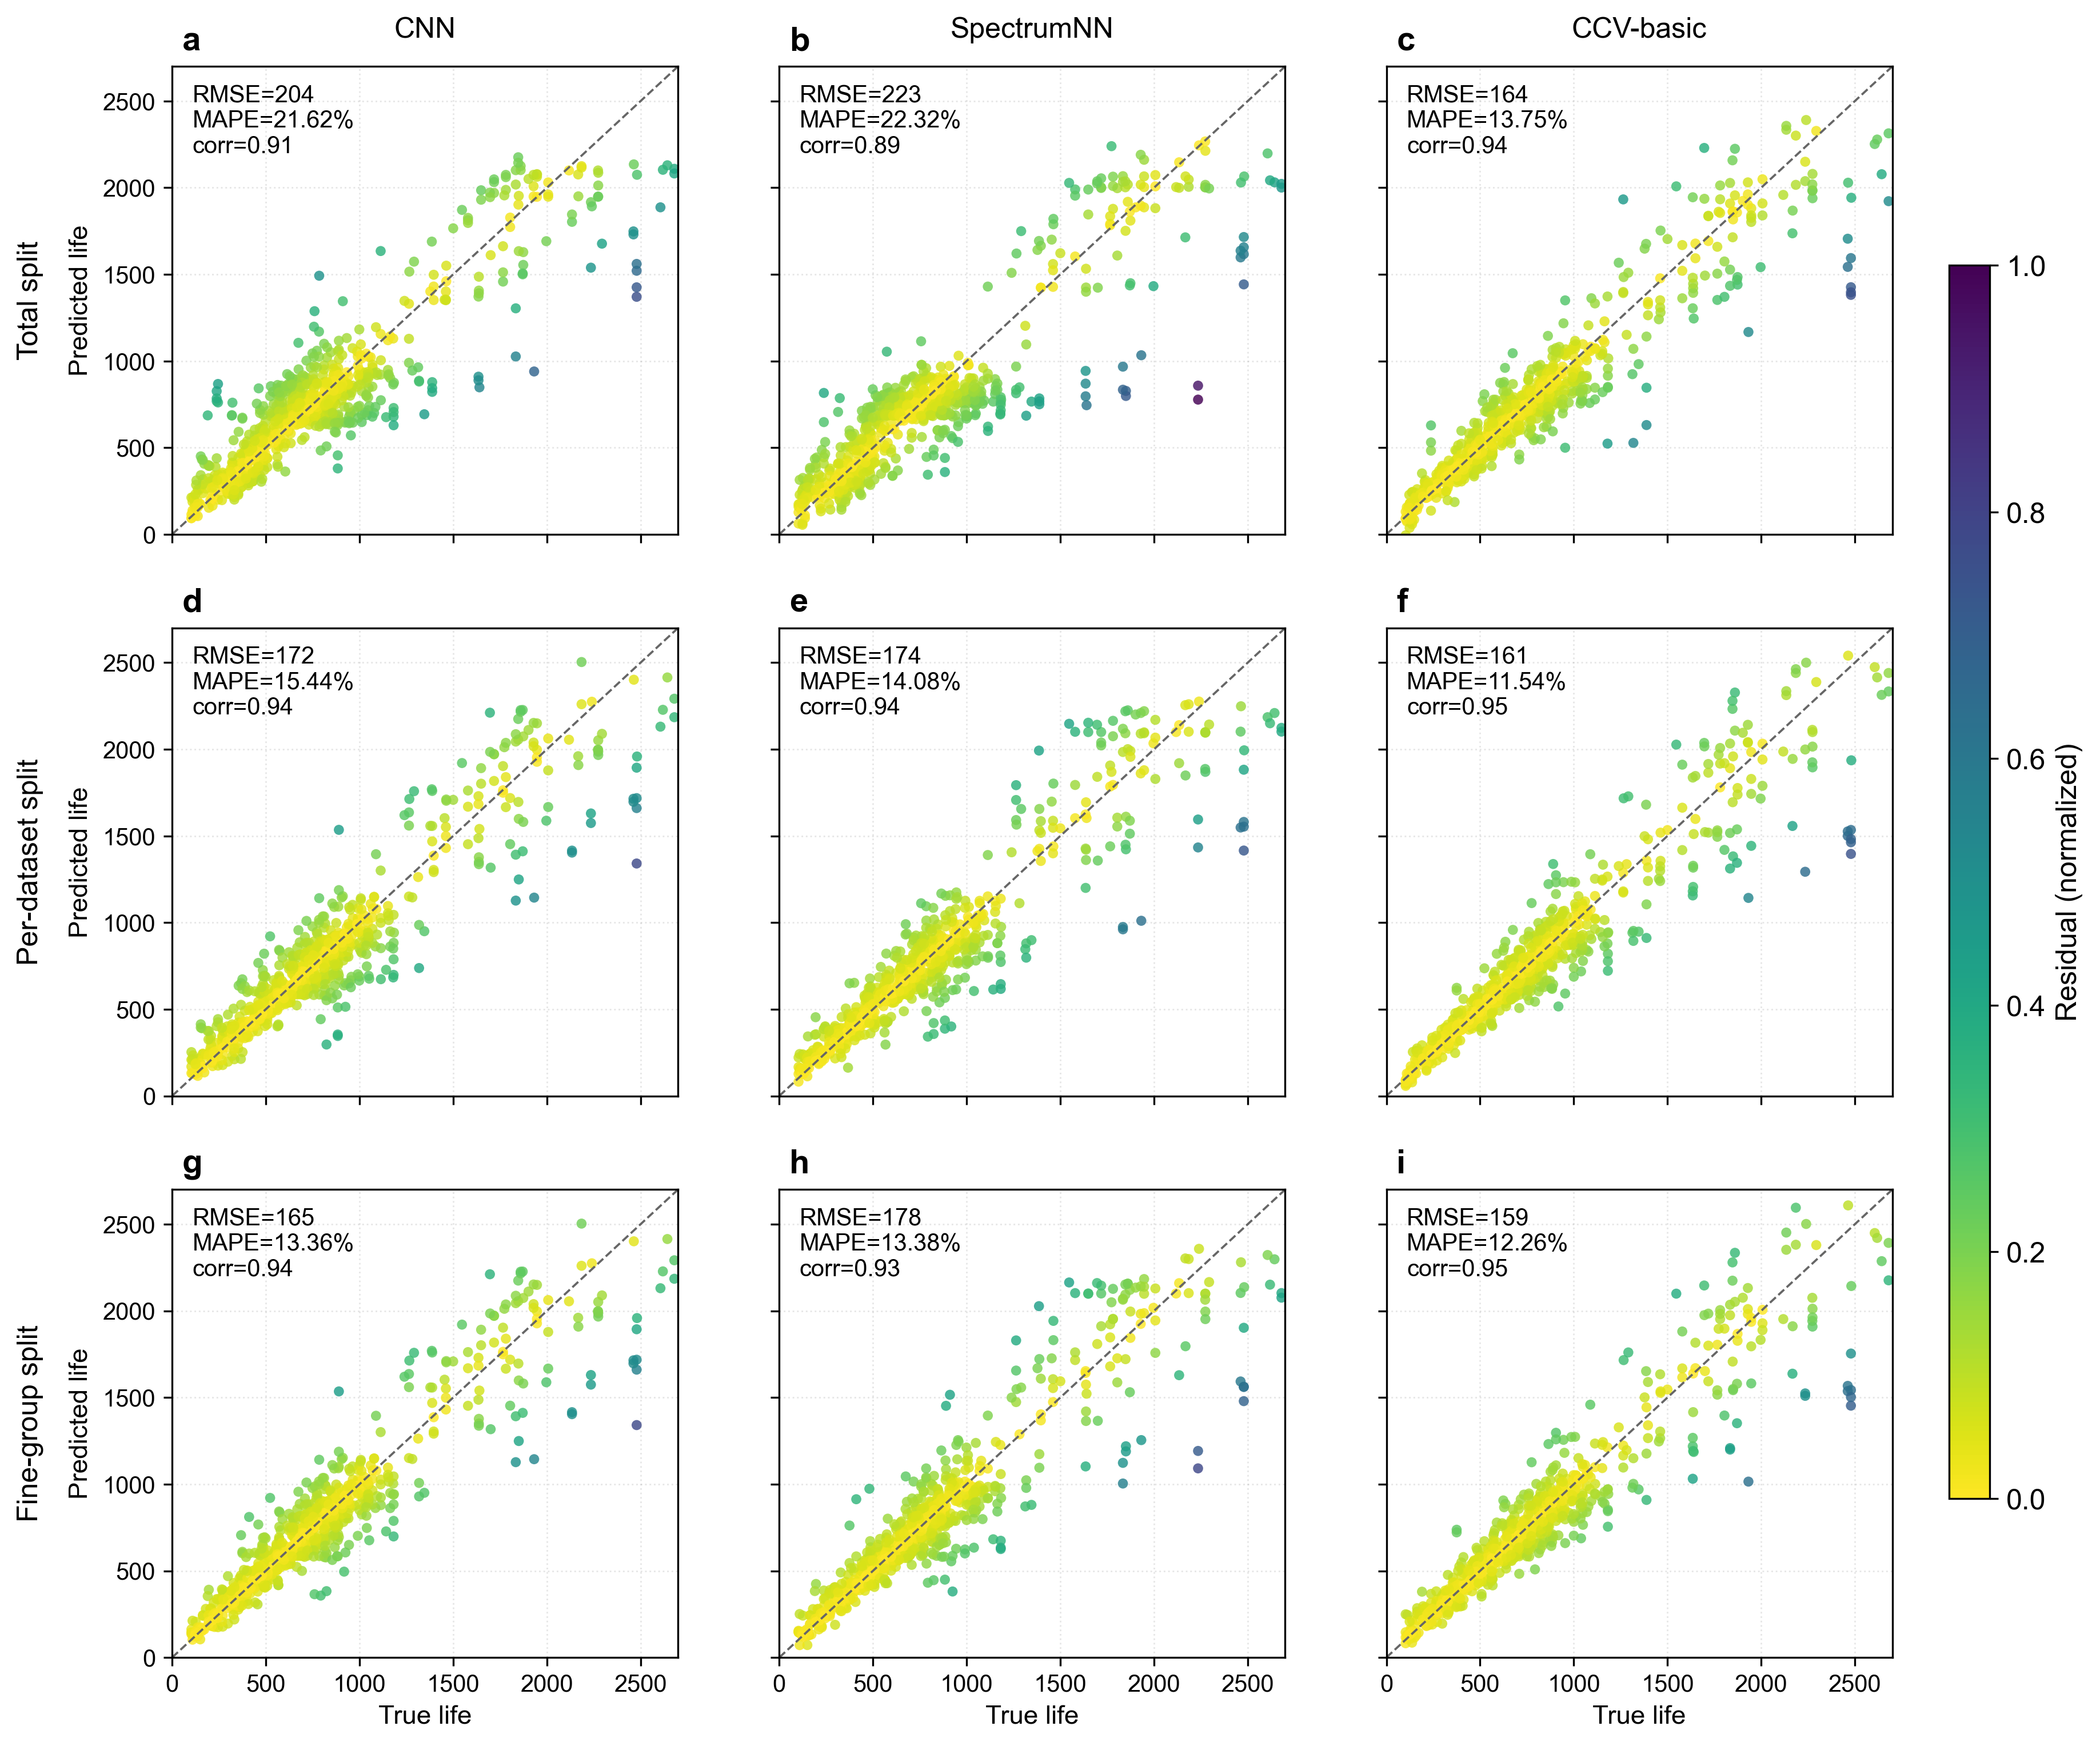

In [ ]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"]
})

major_pred_df = main_baseline_prediction_df.loc[main_baseline_prediction_df["plot_group"].eq("major")].copy()
if major_pred_df.empty:
    print("No major prediction rows found in Main baseline cache.")
else:
    import matplotlib as mpl

    split_order = ["total split", "per-dataset split", "fine-group split"]
    split_label_map = {
        "total split": "Total split",
        "per-dataset split": "Per-dataset split",
        "fine-group split": "Fine-group split",
    }
    major_specs = [
        ("CNN", "norm"),
        ("SpectrumNN", "norm"),
        ("CCV-basic", "abs"),
    ]
    model_label_map = {
        ("CNN", "norm"): "CNN",
        ("SpectrumNN", "norm"): "SpectrumNN",
        ("CCV-basic", "abs"): "CCV-basic",
    }

    major_pred_df["target_life"] = pd.to_numeric(major_pred_df["target_life"], errors="coerce")
    major_pred_df["prediction"] = pd.to_numeric(major_pred_df["prediction"], errors="coerce")
    major_pred_df["residual"] = major_pred_df["prediction"] - major_pred_df["target_life"]
    major_pred_df["abs_residual"] = major_pred_df["residual"].abs()
    major_pred_df = major_pred_df.loc[
        major_pred_df["target_life"].notna() & major_pred_df["prediction"].notna()
    ].copy()

    if major_pred_df.empty:
        print("No valid major prediction rows available for Main baseline scatter grid.")
    else:
        abs_residual_max = float(major_pred_df["abs_residual"].max())
        if not np.isfinite(abs_residual_max) or abs_residual_max <= 1e-12:
            major_pred_df["abs_residual_norm"] = 0.0
        else:
            major_pred_df["abs_residual_norm"] = (
                major_pred_df["abs_residual"] / abs_residual_max
            ).clip(0.0, 1.0)

        axis_max = float(
            np.nanmax(
                np.r_[
                    major_pred_df["target_life"].to_numpy(dtype=float),
                    major_pred_df["prediction"].to_numpy(dtype=float),
                ]
            )
        )
        axis_max = max(200.0, np.ceil(axis_max / 100.0) * 100.0)

        fig, axes = plt.subplots(3, 3, figsize=(13.2, 11.6), dpi=300, sharex=True, sharey=True)
        cmap = plt.cm.viridis_r
        norm = mpl.colors.Normalize(vmin=0.0, vmax=1.0)

        for row_idx, split_name in enumerate(split_order):
            for col_idx, spec_key in enumerate(major_specs):
                model_name, input_mode = spec_key
                ax = axes[row_idx, col_idx]
                sub = major_pred_df.loc[
                    major_pred_df["split_protocol"].eq(split_name)
                    & major_pred_df["model"].eq(model_name)
                    & major_pred_df["input_mode"].eq(input_mode)
                ].copy()

                if sub.empty:
                    ax.set_visible(False)
                    continue

                ax.scatter(
                    sub["target_life"].to_numpy(dtype=float),
                    sub["prediction"].to_numpy(dtype=float),
                    c=sub["abs_residual_norm"].to_numpy(dtype=float),
                    cmap=cmap,
                    norm=norm,
                    s=18,
                    alpha=0.82,
                    edgecolor="none",
                    rasterized=True,
                )
                ax.plot([0, axis_max], [0, axis_max], linestyle="--", color="#666666", linewidth=0.9, zorder=1)
                ax.set_xlim(0, axis_max)
                ax.set_ylim(0, axis_max)
                ax.grid(linestyle=":", linewidth=0.7, alpha=0.30)
                ax.set_axisbelow(True)

                if row_idx == 0:
                    ax.set_title(model_label_map[spec_key], fontsize=12, pad=12)
                if col_idx == 0:
                    ax.text(
                        -0.28,
                        0.5,
                        split_label_map[split_name],
                        transform=ax.transAxes,
                        rotation=90,
                        ha="center",
                        va="center",
                        fontsize=12,
                    )
                if row_idx == len(split_order) - 1:
                    ax.set_xlabel("True life", fontsize=11)
                if col_idx == 0:
                    ax.set_ylabel("Predicted life", fontsize=11)

                # Add subplot label (a, b, c, ...) in the upper-left corner
                label_idx = row_idx * 3 + col_idx
                label_char = chr(ord('a') + label_idx)
                ax.text(
                    0.02,
                    1.02,
                    label_char,
                    transform=ax.transAxes,
                    ha="left",
                    va="bottom",
                    fontsize=14,
                    fontweight="bold",
                )

                metrics = regression_metrics(
                    sub["target_life"].to_numpy(dtype=float),
                    sub["prediction"].to_numpy(dtype=float),
                )
                ax.text(
                    0.04,
                    0.96,
                    f"RMSE={metrics['rmse']:.0f}\nMAPE={metrics['mape']:.2f}%\ncorr={metrics['pearson_r']:.2f}",
                    transform=ax.transAxes,
                    ha="left",
                    va="top",
                    fontsize=10,
                )

        fig.subplots_adjust(left=0.11, right=0.87, bottom=0.1, top=0.9, wspace=0.2, hspace=0.2)
        cax = fig.add_axes([0.895, 0.18, 0.018, 0.62])
        sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cax)
        cbar.set_label("Residual (normalized)", fontsize=12)
        cbar.ax.tick_params(labelsize=12)

        #plt.savefig(FIGURE_DIR / "S7-1.tiff", dpi=500, format="tiff", bbox_inches="tight")
        plt.show()

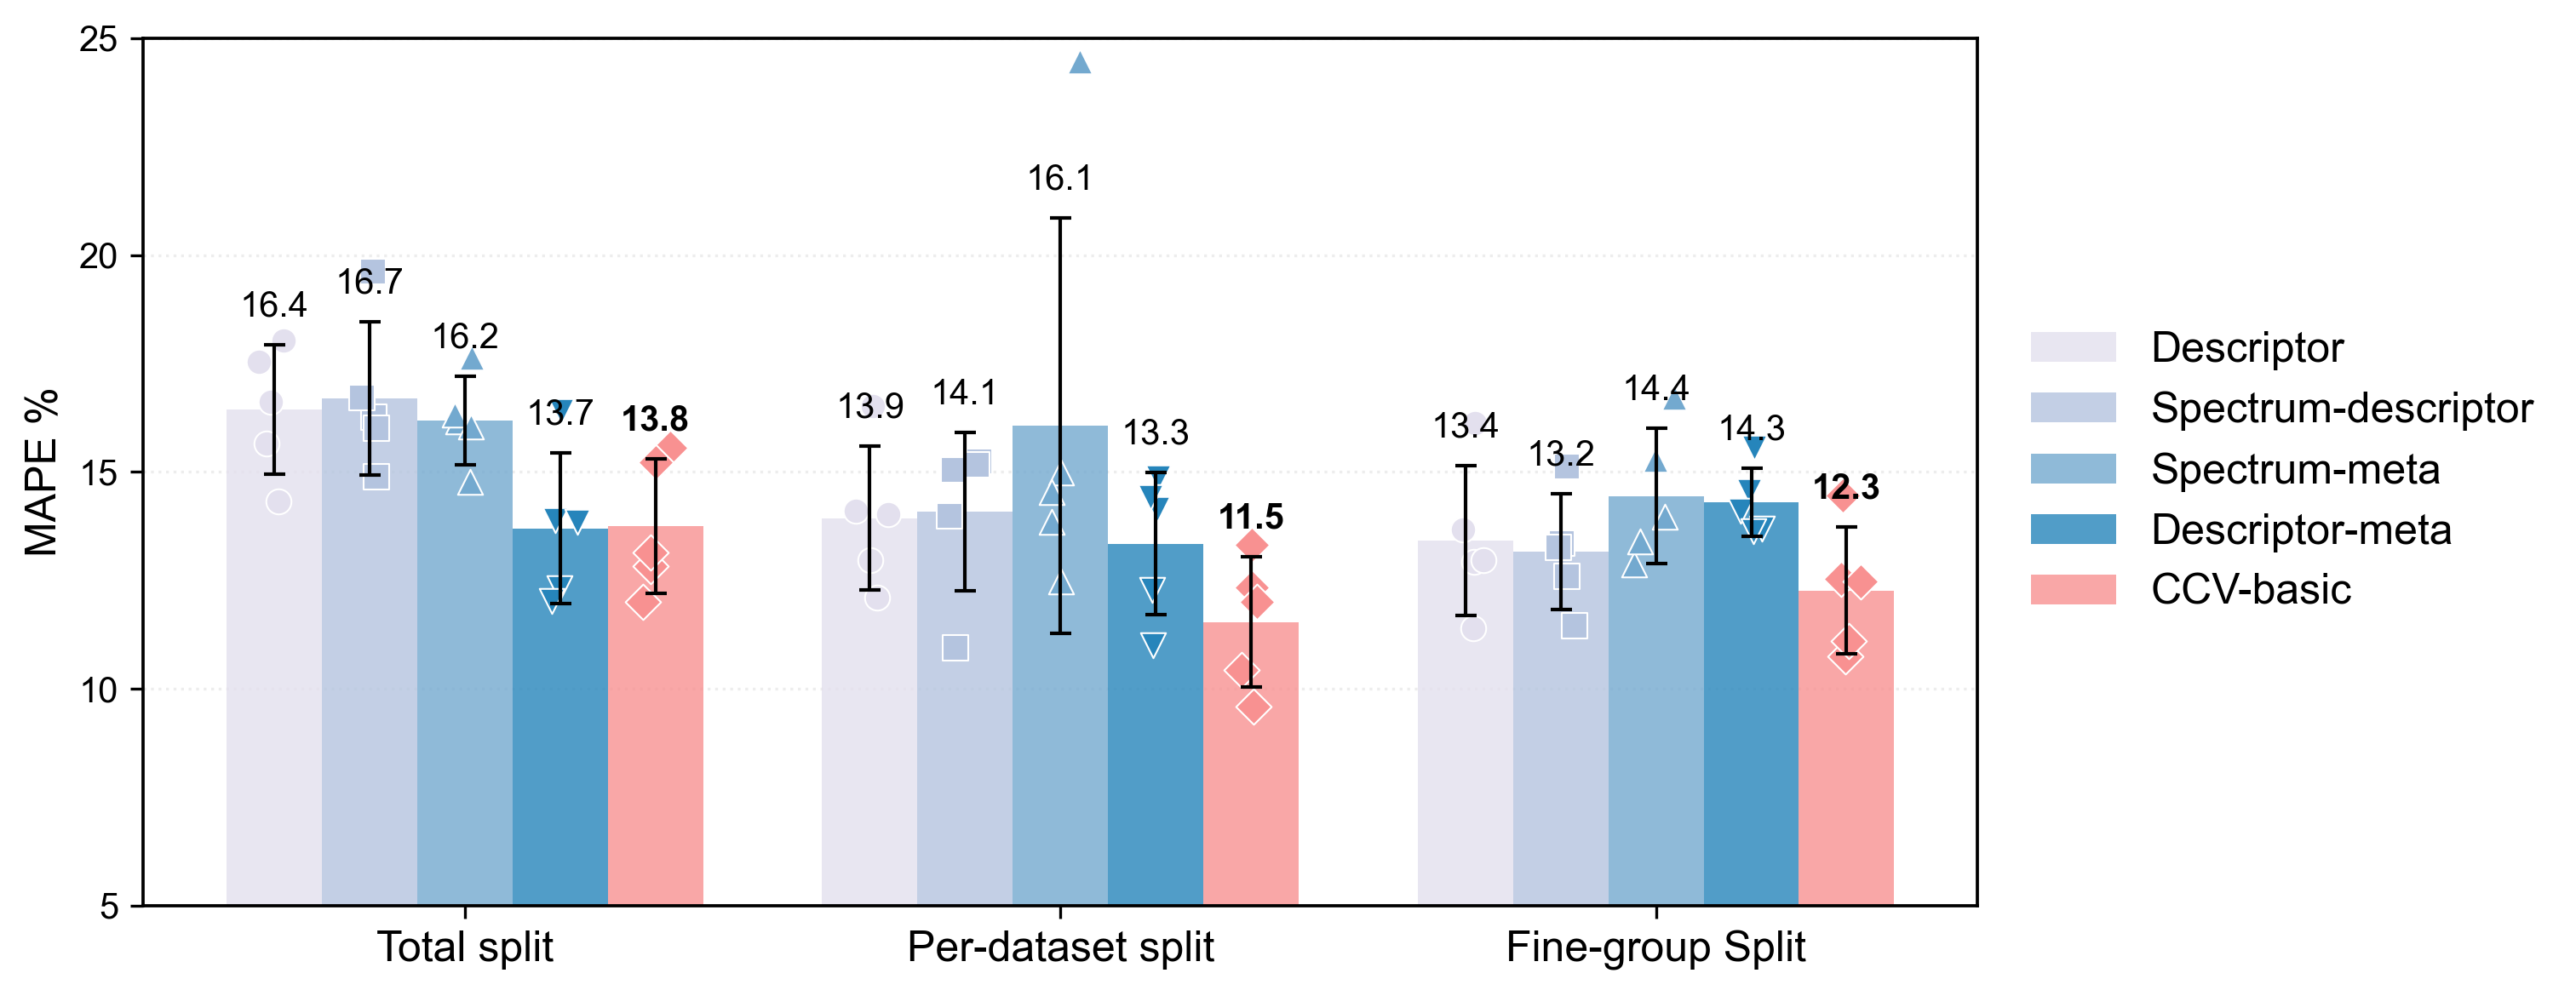

In [ ]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"]
})

plot_df = pd.concat(
    [
        main_baseline_overall_summary_df.loc[
            main_baseline_overall_summary_df["plot_group"].eq("major")
            & main_baseline_overall_summary_df["model"].eq("CCV-basic")
            & main_baseline_overall_summary_df["input_mode"].eq("abs")
        ].copy(),
        main_baseline_overall_summary_df.loc[
            main_baseline_overall_summary_df["plot_group"].eq("ablation")
            & (
                (
                    main_baseline_overall_summary_df["model"].eq("Descriptor")
                    & main_baseline_overall_summary_df["input_mode"].eq("abs")
                )
                | (
                    main_baseline_overall_summary_df["model"].eq("Spectrum-descriptor")
                    & main_baseline_overall_summary_df["input_mode"].eq("abs")
                )
                | (
                    main_baseline_overall_summary_df["model"].eq("Spectrum-meta")
                    & main_baseline_overall_summary_df["input_mode"].eq("abs")
                )
                | (
                    main_baseline_overall_summary_df["model"].eq("Descriptor-meta")
                    & main_baseline_overall_summary_df["input_mode"].eq("abs")
                )
            )
        ].copy(),
    ],
    ignore_index=True,
)

metric_plot_df = pd.concat(
    [
        main_baseline_overall_metric_df.loc[
            main_baseline_overall_metric_df["plot_group"].eq("major")
            & main_baseline_overall_metric_df["model"].eq("CCV-basic")
            & main_baseline_overall_metric_df["input_mode"].eq("abs")
        ].copy(),
        main_baseline_overall_metric_df.loc[
            main_baseline_overall_metric_df["plot_group"].eq("ablation")
            & (
                (
                    main_baseline_overall_metric_df["model"].eq("Descriptor")
                    & main_baseline_overall_metric_df["input_mode"].eq("abs")
                )
                | (
                    main_baseline_overall_metric_df["model"].eq("Spectrum-descriptor")
                    & main_baseline_overall_metric_df["input_mode"].eq("abs")
                )
                | (
                    main_baseline_overall_metric_df["model"].eq("Spectrum-meta")
                    & main_baseline_overall_metric_df["input_mode"].eq("abs")
                )
                | (
                    main_baseline_overall_metric_df["model"].eq("Descriptor-meta")
                    & main_baseline_overall_metric_df["input_mode"].eq("abs")
                )
            )
        ].copy(),
    ],
    ignore_index=True,
)

if plot_df.empty:
    print("No CCV-basic / ablation comparison rows found in Main baseline cache.")
else:
    import seaborn as sns

    split_order = ["total split", "per-dataset split", "fine-group split"]
    split_label_map = {
        "total split": "Total split",
        "per-dataset split": "Per-dataset split",
        "fine-group split": "Fine-group Split",
    }

    compare_specs = [
        ("Descriptor", "abs", "ablation"),
        ("Spectrum-descriptor", "abs", "ablation"),
        ("Spectrum-meta", "abs", "ablation"),
        ("Descriptor-meta", "abs", "ablation"),
        ("CCV-basic", "abs", "major"),
    ]
    label_map = {
        ("Descriptor", "abs", "ablation"): "Descriptor",
        ("Spectrum-descriptor", "abs", "ablation"): "Spectrum-descriptor",
        ("Spectrum-meta", "abs", "ablation"): "Spectrum-meta",
        ("Descriptor-meta", "abs", "ablation"): "Descriptor-meta",
        ("CCV-basic", "abs", "major"): "CCV-basic",
    }
    pubu_colors = sns.color_palette("PuBu", 5)
    palette = {
        ("Descriptor", "abs", "ablation"): pubu_colors[0],
        ("Spectrum-descriptor", "abs", "ablation"): pubu_colors[1],
        ("Spectrum-meta", "abs", "ablation"): pubu_colors[2],
        ("Descriptor-meta", "abs", "ablation"): pubu_colors[3],
        ("CCV-basic", "abs", "major"): "#f89191",
    }
    scatter_style = {
        ("Descriptor", "abs", "ablation"): dict(marker="o"),
        ("Spectrum-descriptor", "abs", "ablation"): dict(marker="s"),
        ("Spectrum-meta", "abs", "ablation"): dict(marker="^"),
        ("Descriptor-meta", "abs", "ablation"): dict(marker="v"),
        ("CCV-basic", "abs", "major"): dict(marker="D"),
    }

    fig, ax = plt.subplots(figsize=(10.2, 4), dpi=300)
    x = np.arange(len(split_order), dtype=float)
    width = 0.16

    for idx, spec_key in enumerate(compare_specs):
        model_name, input_mode, plot_group = spec_key
        sub = (
            plot_df.loc[
                plot_df["model"].eq(model_name)
                & plot_df["input_mode"].eq(input_mode)
                & plot_df["plot_group"].eq(plot_group)
            ]
            .set_index("split_protocol")
            .reindex(split_order)
            .reset_index()
        )

        xpos = x + (idx - (len(compare_specs) - 1) / 2.0) * width
        mean_values = sub["mape"].to_numpy(dtype=float)
        std_values = sub["mape_std"].fillna(0.0).to_numpy(dtype=float)

        bars = ax.bar(
            xpos,
            mean_values,
            width=width,
            color=palette[spec_key],
            edgecolor="none",
            linewidth=0.0,
            alpha=0.8,
            zorder=2,
            label=label_map[spec_key],
        )

        ax.errorbar(
            xpos,
            mean_values,
            yerr=std_values,
            fmt="none",
            capsize=3,
            elinewidth=1.0,
            capthick=1.0,
            ecolor="#000000",
            alpha=1.0,
            zorder=5,
        )

        rep_sub = metric_plot_df.loc[
            metric_plot_df["model"].eq(model_name)
            & metric_plot_df["input_mode"].eq(input_mode)
            & metric_plot_df["plot_group"].eq(plot_group)
        ].copy()

        rng = np.random.default_rng(1700 + idx)
        for split_idx, split_name in enumerate(split_order):
            split_rep = rep_sub.loc[rep_sub["split_protocol"].eq(split_name)].copy()
            if split_rep.empty:
                continue
            jitter = rng.normal(0.0, width * 0.10, size=len(split_rep))
            scatter_x = np.full(len(split_rep), xpos[split_idx], dtype=float) + jitter
            scatter_y = split_rep["mape"].to_numpy(dtype=float)
            ax.scatter(
                scatter_x,
                scatter_y,
                s=50,
                facecolor=palette[spec_key],
                edgecolor="white",
                linewidth=0.5,
                zorder=4,
                **scatter_style[spec_key],
            )

        for bar, mean_v, std_v in zip(bars, mean_values, std_values):
            if np.isfinite(mean_v):
                y_text = mean_v + std_v + 0.5
                ax.text(
                    bar.get_x() + bar.get_width() / 2.0,
                    y_text,
                    f"{mean_v:.1f}",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                    color="#000000",
                    fontweight="bold" if spec_key == ("CCV-basic", "abs", "major") else "normal",
                    zorder=5,
                )

    ax.set_xticks(x)
    ax.set_xticklabels([split_label_map[s] for s in split_order], fontsize=12)
    ax.set_ylabel("MAPE %", fontsize=12)
    ax.set_ylim(5, 25)
    ax.set_yticks([5, 10, 15, 20, 25])
    ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.22, zorder=0)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_linewidth(0.9)
        spine.set_color("#000000")

    ax.tick_params(axis="y", labelsize=10)
    ax.legend(
        frameon=False,
        fontsize=12,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        ncol=1,
    )
    fig.tight_layout()
    #plt.savefig(FIGURE_DIR / "S12-1.tiff", format="tiff", dpi=500, bbox_inches="tight")
    plt.show()


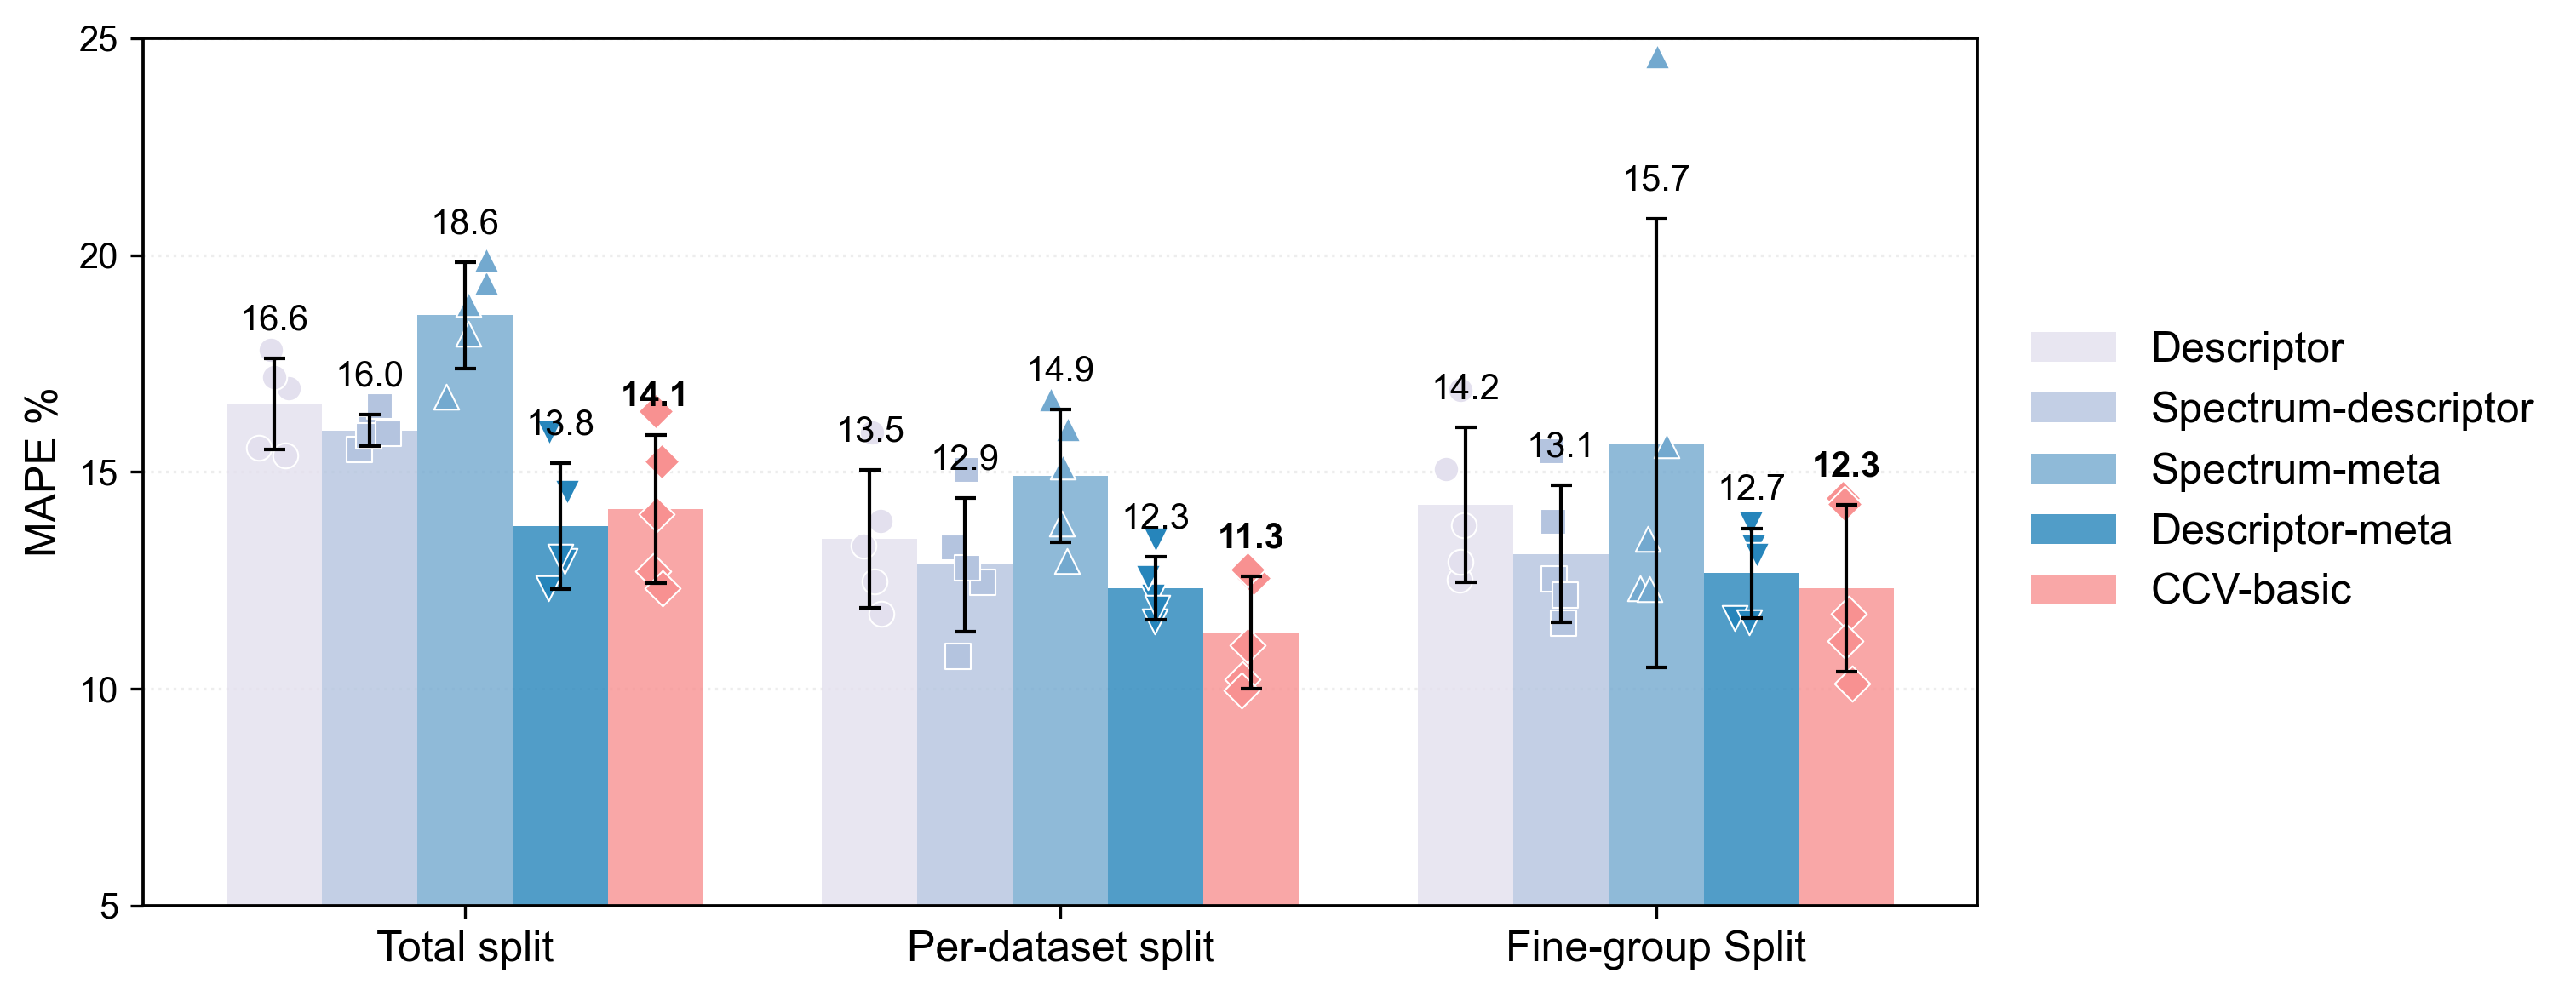

In [ ]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"]
})

plot_df = pd.concat(
    [
        main_baseline_overall_summary_df.loc[
            main_baseline_overall_summary_df["plot_group"].eq("ablation")
            & main_baseline_overall_summary_df["model"].eq("CCV-norm")
            & main_baseline_overall_summary_df["input_mode"].eq("norm")
        ].copy(),
        main_baseline_overall_summary_df.loc[
            main_baseline_overall_summary_df["plot_group"].eq("ablation")
            & main_baseline_overall_summary_df["input_mode"].eq("norm")
            & main_baseline_overall_summary_df["model"].isin([
                "Descriptor",
                "Spectrum-descriptor",
                "Spectrum-meta",
                "Descriptor-meta",
            ])
        ].copy(),
    ],
    ignore_index=True,
)

metric_plot_df = pd.concat(
    [
        main_baseline_overall_metric_df.loc[
            main_baseline_overall_metric_df["plot_group"].eq("ablation")
            & main_baseline_overall_metric_df["model"].eq("CCV-norm")
            & main_baseline_overall_metric_df["input_mode"].eq("norm")
        ].copy(),
        main_baseline_overall_metric_df.loc[
            main_baseline_overall_metric_df["plot_group"].eq("ablation")
            & main_baseline_overall_metric_df["input_mode"].eq("norm")
            & main_baseline_overall_metric_df["model"].isin([
                "Descriptor",
                "Spectrum-descriptor",
                "Spectrum-meta",
                "Descriptor-meta",
            ])
        ].copy(),
    ],
    ignore_index=True,
)

if plot_df.empty:
    print("No CCV-norm / norm-ablation comparison rows found in Main baseline cache.")
else:
    import seaborn as sns

    split_order = ["total split", "per-dataset split", "fine-group split"]
    split_label_map = {
        "total split": "Total split",
        "per-dataset split": "Per-dataset split",
        "fine-group split": "Fine-group Split",
    }

    compare_specs = [
        ("Descriptor", "norm", "ablation"),
        ("Spectrum-descriptor", "norm", "ablation"),
        ("Spectrum-meta", "norm", "ablation"),
        ("Descriptor-meta", "norm", "ablation"),
        ("CCV-norm", "norm", "ablation"),
    ]
    label_map = {
        ("Descriptor", "norm", "ablation"): "Descriptor",
        ("Spectrum-descriptor", "norm", "ablation"): "Spectrum-descriptor",
        ("Spectrum-meta", "norm", "ablation"): "Spectrum-meta",
        ("Descriptor-meta", "norm", "ablation"): "Descriptor-meta",
        ("CCV-norm", "norm", "ablation"): "CCV-basic",
    }
    pubu_colors = sns.color_palette("PuBu", 5)
    palette = {
        ("Descriptor", "norm", "ablation"): pubu_colors[0],
        ("Spectrum-descriptor", "norm", "ablation"): pubu_colors[1],
        ("Spectrum-meta", "norm", "ablation"): pubu_colors[2],
        ("Descriptor-meta", "norm", "ablation"): pubu_colors[3],
        ("CCV-norm", "norm", "ablation"): "#f89191",
    }
    scatter_style = {
        ("Descriptor", "norm", "ablation"): dict(marker="o"),
        ("Spectrum-descriptor", "norm", "ablation"): dict(marker="s"),
        ("Spectrum-meta", "norm", "ablation"): dict(marker="^"),
        ("Descriptor-meta", "norm", "ablation"): dict(marker="v"),
        ("CCV-norm", "norm", "ablation"): dict(marker="D"),
    }

    fig, ax = plt.subplots(figsize=(10.2, 4), dpi=300)
    x = np.arange(len(split_order), dtype=float)
    width = 0.16

    for idx, spec_key in enumerate(compare_specs):
        model_name, input_mode, plot_group = spec_key
        sub = (
            plot_df.loc[
                plot_df["model"].eq(model_name)
                & plot_df["input_mode"].eq(input_mode)
                & plot_df["plot_group"].eq(plot_group)
            ]
            .set_index("split_protocol")
            .reindex(split_order)
            .reset_index()
        )

        xpos = x + (idx - (len(compare_specs) - 1) / 2.0) * width
        mean_values = sub["mape"].to_numpy(dtype=float)
        std_values = sub["mape_std"].fillna(0.0).to_numpy(dtype=float)

        bars = ax.bar(
            xpos,
            mean_values,
            width=width,
            color=palette[spec_key],
            edgecolor="none",
            linewidth=0.0,
            alpha=0.8,
            zorder=2,
            label=label_map[spec_key],
        )

        ax.errorbar(
            xpos,
            mean_values,
            yerr=std_values,
            fmt="none",
            capsize=3,
            elinewidth=1.0,
            capthick=1.0,
            ecolor="#000000",
            alpha=1.0,
            zorder=5,
        )

        rep_sub = metric_plot_df.loc[
            metric_plot_df["model"].eq(model_name)
            & metric_plot_df["input_mode"].eq(input_mode)
            & metric_plot_df["plot_group"].eq(plot_group)
        ].copy()

        rng = np.random.default_rng(2700 + idx)
        for split_idx, split_name in enumerate(split_order):
            split_rep = rep_sub.loc[rep_sub["split_protocol"].eq(split_name)].copy()
            if split_rep.empty:
                continue
            jitter = rng.normal(0.0, width * 0.10, size=len(split_rep))
            scatter_x = np.full(len(split_rep), xpos[split_idx], dtype=float) + jitter
            scatter_y = split_rep["mape"].to_numpy(dtype=float)
            ax.scatter(
                scatter_x,
                scatter_y,
                s=50,
                facecolor=palette[spec_key],
                edgecolor="white",
                linewidth=0.5,
                zorder=4,
                **scatter_style[spec_key],
            )

        for bar, mean_v, std_v in zip(bars, mean_values, std_values):
            if np.isfinite(mean_v):
                y_text = mean_v + std_v + 0.5
                ax.text(
                    bar.get_x() + bar.get_width() / 2.0,
                    y_text,
                    f"{mean_v:.1f}",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                    color="#000000",
                    fontweight="bold" if spec_key == ("CCV-norm", "norm", "ablation") else "normal",
                    zorder=5,
                )

    ax.set_xticks(x)
    ax.set_xticklabels([split_label_map[s] for s in split_order], fontsize=12)
    ax.set_ylabel("MAPE %", fontsize=12)
    ax.set_ylim(5, 25)
    ax.set_yticks([5, 10, 15, 20, 25])
    ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.22, zorder=0)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_linewidth(0.9)
        spine.set_color("#000000")

    ax.tick_params(axis="y", labelsize=10)
    ax.legend(
        frameon=False,
        fontsize=12,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        ncol=1,
    )
    fig.tight_layout()
    #plt.savefig(FIGURE_DIR / "S12-2.tiff", format="tiff", dpi=500, bbox_inches="tight")
    plt.show()
